In [ ]:
#runtime on python3
from google.colab import drive
drive.mount('/content/data')

Mounted at /content/data


In [ ]:
#runtime on R
library(tidyverse)
# データの読み込み
data <- read_csv("data/My Drive/data/speed_heading_data2025.csv")

# データ構造の確認
str(data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 5984991 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Session, Condition
dbl (6): Cohort, Fish, Track, Time, Speed, Heading

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


spc_tbl_ [5,984,991 × 8] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Session  : chr [1:5984991] "2025-05-28 10-01-55_vmc_checked.mat" "2025-05-28 10-01-55_vmc_checked.mat" "2025-05-28 10-01-55_vmc_checked.mat" "2025-05-28 10-01-55_vmc_checked.mat" ...
 $ Condition: chr [1:5984991] "beringSea" "beringSea" "beringSea" "beringSea" ...
 $ Cohort   : num [1:5984991] 1 1 1 1 1 1 1 1 1 1 ...
 $ Fish     : num [1:5984991] 1 1 1 1 1 1 1 1 1 1 ...
 $ Track    : num [1:5984991] 1 1 1 1 1 1 1 1 1 1 ...
 $ Time     : num [1:5984991] 0.0333 0.0667 0.1 0.1333 0.1667 ...
 $ Speed    : num [1:5984991] 6.65 3.45 4.43 6 5.76 ...
 $ Heading  : num [1:5984991] -35.9 -35.3 -35.5 -35.9 -36 ...
 - attr(*, "spec")=
  .. cols(
  ..   Session = col_character(),
  ..   Condition = col_character(),
  ..   Cohort = col_double(),
  ..   Fish = col_double(),
  ..   Track = col_double(),
  ..   Time = col_double(),
  ..   Speed = col_double(),
  ..   Heading = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


In [ ]:

# 必要なパッケージのインストールとロード
if (!require(circular)) install.packages("circular")
if (!require(multcomp)) install.packages("multcomp")

# パッケージのロード
library(circular)
library(multcomp)

Loading required package: circular

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘circular’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘mvtnorm’


Loading required package: multcomp

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘multcomp’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘TH.data’, ‘sandwich’



Attaching package: ‘circular’


The following objects are masked from ‘package:stats’:

    sd, var


Loading required package: mvtnorm

Loading required package: survival

Loading required package: TH.data

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select



Attaching package: ‘TH.data’




In [ ]:
if (!require(emmeans)) install.packages("emmeans")

Loading required package: emmeans

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘emmeans’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘estimability’, ‘numDeriv’




In [ ]:
# @title
perform_anova_and_posthoc <- function(input_data, control_label, condition_group, group_label) {
  # Combine control data with experimental data for ANOVA
  anova_data <- data.frame()
  anova_conditions <- c()
  anova_groups <- c()
  anova_fish <- c()

  # Filter out specified control and condition data
  control_data <- input_data[input_data$Condition == control_label, ]
  for (i in 1:length(condition_group)) {
    condition <- condition_group[i]
    condition_data <- input_data[input_data$Condition == condition, ]

    # Combine control and condition data
    combined_data <- rbind(control_data, condition_data)
    combined_conditions <- c(rep(control_label, nrow(control_data)), rep(condition, nrow(condition_data)))
    combined_groups <- rep(group_label, nrow(combined_data))
    combined_fish <- c(control_data$Fish, condition_data$Fish)

    # Append to ANOVA data
    anova_data <- rbind(anova_data, combined_data)
    anova_conditions <- c(anova_conditions, combined_conditions)
    anova_groups <- c(anova_groups, combined_groups)
    anova_fish <- c(anova_fish, combined_fish)
  }

  # Convert data for Repeated Measures ANOVA
  # Ensure Fish and Condition are factors
  anova_table <- data.frame(
    Condition = factor(anova_conditions),
    Group = factor(anova_groups),
    Fish = factor(anova_fish), # Fish is the subject factor
    Speed = anova_data$Speed,
    Distance_10s = anova_data$Distance_10s
  )

  # Perform Repeated Measures ANOVA
  # Using anovata_table for the analysis
  anova_results_speed <- aov(Speed ~ Condition + Error(Fish/Condition), data = anova_table)
  anova_results_distance <- aov(Distance_10s ~ Condition + Error(Fish/Condition), data = anova_table)


  # Display results
  cat("***---***\n")
  cat("Results for", group_label, "conditions (Repeated Measures ANOVA):\n")

  cat("\nANOVA Results for Speed:\n")
  print(summary(anova_results_speed))

  cat("\nANOVA Results for Distance_10s:\n")
  print(summary(anova_results_distance))


  # Post-hoc tests for Repeated Measures ANOVA using emmeans
  cat("\nPerforming post-hoc tests using emmeans (Estimated Marginal Means):\n")

  # For Speed
  cat("\nPost-hoc tests for Speed:\n")
  tryCatch({
    library(emmeans)
    # Create a linear model from the aov object for use with emmeans
    model_speed_lm <- lm(Speed ~ Condition, data = anova_table)
    posthoc_speed <- emmeans(model_speed_lm, ~ Condition, adjust = "tukey") # Tukey adjustment for multiple comparisons
    print(pairs(posthoc_speed))
  }, error = function(e) {
    cat("Could not perform post-hoc tests for Speed. Error:", e$message, "\n")
    cat("Ensure 'emmeans' package is installed and loaded, and the model is suitable.\n")
  })


  # For Distance_10s
  cat("\nPost-hoc tests for Distance_10s:\n")
    tryCatch({
    library(emmeans)
    # Create a linear model from the aov object for use with emmeans
    model_distance_lm <- lm(Distance_10s ~ Condition, data = anova_table)
    posthoc_distance <- emmeans(model_distance_lm, ~ Condition, adjust = "tukey") # Tukey adjustment for multiple comparisons
    print(pairs(posthoc_distance))
  }, error = function(e) {
    cat("Could not perform post-hoc tests for Distance_10s. Error:", e$message, "\n")
    cat("Ensure 'emmeans' package is installed and loaded, and the model is suitable.\n")
  })


  # Perform Watson-Williams test for Heading
  # Note: Watson-Williams test is for circular data and typically for independent groups.
  # For repeated measures of circular data, more advanced methods or adaptations might be needed.
  heading_data <- anova_data$Heading
  heading_data <- conversion.circular(circular(heading_data, units = "degrees"), units = "radians")
  heading_conditions <- factor(anova_conditions)
  heading_fish <- factor(anova_fish) # Include Fish as a factor for repeated measures consideration if needed


  # Perform pairwise Watson-Williams tests for heading
  # Adapting for potential repeated measures - this is a simplified approach.
  # A proper repeated measures analysis for circular data is more complex.
  significant_pairs <- c()
  p_values <- list()
  unique_conditions <- unique(heading_conditions)
  num_comparisons <- 0

  # Create a data frame for heading analysis
  heading_anova_table <- data.frame(
    Condition = heading_conditions,
    Fish = heading_fish,
    Heading = heading_data
  )

  # Perform pairwise tests only if there's more than one condition
  if (length(unique_conditions) > 1) {
    for (i in 1:length(unique_conditions)) {
      for (j in (i + 1):length(unique_conditions)) {
        cond1 <- unique_conditions[i]
        cond2 <- unique_conditions[j]

        # Filter data for the two conditions
        data1 <- heading_anova_table %>% filter(Condition == cond1)
        data2 <- heading_anova_table %>% filter(Condition == cond2)

        # Ensure both conditions have data and the same fish IDs (for paired comparison)
        # This is a simplification; a proper repeated measures approach would handle this more robustly.
        common_fish <- intersect(data1$Fish, data2$Fish)

        if (length(common_fish) > 0) {
           # Filter data to include only common fish
          data1_filtered <- data1 %>% filter(Fish %in% common_fish)
          data2_filtered <- data2 %>% filter(Fish %in% common_fish)


          # Need to ensure data1_filtered and data2_filtered are aligned by fish for paired test
          # This simple Watson.two.test is for independent groups.
          # For paired circular data, you might consider methods like paired Hotelling's T^2 on transformed data or bootstrapping.
          # As a basic check, we'll perform the independent test but note its limitation.

          if (nrow(data1_filtered) > 0 && nrow(data2_filtered) > 0) {
             p_pairwise <- try(circular::watson.two.test(data1_filtered$Heading, data2_filtered$Heading), silent = TRUE)
             num_comparisons <- num_comparisons + 1
             if (inherits(p_pairwise, "try-error")) {
               cat("Error in Watson-Williams test between", cond1, "and", cond2, "\n")
               next
             }
             if (!is.null(p_pairwise$p.value) && length(p_pairwise$p.value) > 0) {
               p_values[[paste(cond1, "vs", cond2)]] <- p_pairwise$p.value
               # Bonferroni correction (simple)
               if (p_pairwise$p.value < 0.05 / max(1, num_comparisons)) {
                 significant_pairs <- c(significant_pairs, paste(cond1, "vs", cond2, ": p-value =", p_pairwise$p.value))
               }
             }
          }
        }
      }
    }
  }


  # Display results for Heading
  if (length(significant_pairs) > 0) {
    cat("Significant differences found in Heading between conditions (using Watson-Williams test on potentially filtered data):\n")
    for (pair in significant_pairs) {
      cat(pair, "\n")
    }
  } else {
    cat("No significant differences found in Heading between conditions (using Watson-Williams test).\n")
  }

  # Display p-values for each condition pair
  cat("P-values for each condition pair in Heading (Watson-Williams test, before Bonferroni correction):\n")
  if(length(p_values) > 0) {
    for (pair in names(p_values)) {
      cat(pair, ": p-value =", p_values[[pair]], "\n")
    }
  } else {
    cat("No pairwise comparisons performed for Heading.\n")
  }
   cat("Note: Watson-Williams test assumes independence. For repeated measures of circular data, more appropriate methods may be needed.\n")
}

calculateMomentaryActivityIndex <- function(speed) {
  # Calculate the standard deviation of speed and heading variance for each fish
  speed_std <- sd(speed)  # Standard deviation across time points for each fish

  # Define the threshold as 3 times the standard deviation
  speed_threshold <- 3 * speed_std

  # Calculate the activity index as a binary indicator if speed is above the threshold
  is_active_speed <- speed > speed_threshold

  # Combine both conditions for activity index (either condition being true)
  activity_index <- sum(is_active_speed) / length(speed)

  return(activity_index)
}

In [ ]:
# Define constants
fps <- 30
time_limit <- 15 * 60 * fps # 20 minutes in frames
one_minute_frames <- 60 * fps

# Get unique conditions and fish IDs
conditions <- unique(data$Condition)
fish_ids <- unique(data$Fish)

# Initialize arrays to store averaged data
averaged_data <- data.frame()

# Loop through each condition and fish to filter and calculate mean values
for (i in 1:length(conditions)) {
  for (j in 1:length(fish_ids)) {
    # Filter data for the current condition and fish
    condition_fish_data <- data[data$Condition == conditions[i] & data$Fish == fish_ids[j], ]

    # Apply the time limit to speed and heading data
    if (nrow(condition_fish_data) > time_limit) {
      condition_fish_data <- condition_fish_data[(time_limit + 1):nrow(condition_fish_data), ]
    } else {
      next
    }

    # Calculate speed standard deviation and threshold
    speed_std <- sd(condition_fish_data$Speed)
    speed_var <- var(condition_fish_data$Speed)
    speed_threshold <- 3 * speed_std

    # Filter data where speed is below the threshold for heading calculation
    filtered_heading_data <- condition_fish_data[condition_fish_data$Speed <= speed_threshold, ]

    if (nrow(filtered_heading_data) == 0) {
      next
    }

    # Calculate mean heading for filtered data
    mean_heading <- circular::mean.circular(circular::circular(filtered_heading_data$Heading, units = "degrees", template = "geographics"))
    mean_heading_revolutions <- mean(cumsum(c(0, diff(filtered_heading_data$Heading))))

    # Calculate other mean values for unfiltered data
    mean_speed <- mean(condition_fish_data$Speed)
    mean_acceleration <- mean(c(0, diff(condition_fish_data$Speed)))
    mean_activity_frequency <- calculateMomentaryActivityIndex(condition_fish_data$Speed)

    # Calculate average distance moved every 10 seconds
    ten_seconds_frames <- 10 * fps
    distances <- c()
    for (start in seq(1, nrow(condition_fish_data), by = ten_seconds_frames)) {
      end <- min(start + ten_seconds_frames - 1, nrow(condition_fish_data))
      distance <- sum(condition_fish_data$Speed[start:end]) / fps
      distances <- c(distances, distance)
    }
    mean_distance_10s <- mean(distances)

    # Calculate mean speed per minute
    minute_means <- c()
    for (start in seq(1, nrow(condition_fish_data), by = one_minute_frames)) {
      end <- min(start + one_minute_frames - 1, nrow(condition_fish_data))
      minute_mean <- mean(condition_fish_data$Speed[start:end])
      minute_means <- c(minute_means, minute_mean)
    }
    mean_speed_per_minute <- mean(minute_means)


    mean_values <- data.frame(
      Speed = mean_speed,
      Acceleration = mean_acceleration,
      ActivityFrequency = mean_activity_frequency,
      Heading = mean_heading,
      HeadingRevolutions = mean_heading_revolutions,
      Distance_10s = mean_distance_10s,
      SpeedVariance = speed_var,
      MeanSpeedPerMinute = mean_speed_per_minute,
      Fish = fish_ids[j],
      Condition = conditions[i]
    )

    # Append the mean values to the averaged data table
    averaged_data <- rbind(averaged_data, mean_values)
  }
}

#str(averaged_data)
#names(averaged_data)
# averaged_data

# Define control conditions for different types of conditions
control_sea <- "controlSea1"
control_rot <- "controlT1"
control_t1 <- "controlT1"


# Separate data into different experimental groups, excluding specified controls
sea_conditions <- setdiff(conditions[grep("Sea", conditions)], control_sea)
rot_conditions <- setdiff(conditions[grep("rotation|controlT", conditions)], control_rot)
microt_conditions <- setdiff(conditions[grep("microT|controlT", conditions)], control_t1)

# Print the content of sea_conditions
print("Conditions:")
print(sea_conditions)
print(rot_conditions)
print(microt_conditions)

# Perform ANOVA and post-hoc tests for Sea conditions
group_label <- "Sea"
perform_anova_and_posthoc(averaged_data, control_sea, sea_conditions, group_label)

# Perform ANOVA and post-hoc tests for Rot conditions
group_label <- "rotation"
perform_anova_and_posthoc(averaged_data, control_rot, rot_conditions, group_label)

# Perform ANOVA and post-hoc tests for microT conditions
group_label <- "microT"
perform_anova_and_posthoc(averaged_data, control_t1, microt_conditions, group_label)

[1] "Conditions:"
[1] "beringSea"  "okhotskSea"
[1] "rotation90"
[1] "microT100" "microT10" 


Warning message in aov(Speed ~ Condition + Error(Fish/Condition), data = anova_table):
“Error() model is singular”
Warning message in aov(Distance_10s ~ Condition + Error(Fish/Condition), data = anova_table):
“Error() model is singular”


***---***
Results for Sea conditions (Repeated Measures ANOVA):

ANOVA Results for Speed:

Error: Fish
          Df  Sum Sq Mean Sq F value Pr(>F)
Condition  2   84995   42498   0.513  0.603
Residuals 33 2731948   82786               

Error: Fish:Condition
          Df  Sum Sq Mean Sq F value Pr(>F)
Condition  2  221532  110766   2.137  0.126
Residuals 67 3471998   51821               

Error: Within
          Df    Sum Sq   Mean Sq F value Pr(>F)
Residuals 36 1.417e-24 3.935e-26               

ANOVA Results for Distance_10s:

Error: Fish
          Df   Sum Sq Mean Sq F value Pr(>F)
Condition  2  1204423  602212   0.786  0.464
Residuals 33 25288703  766324               

Error: Fish:Condition
          Df   Sum Sq Mean Sq F value Pr(>F)
Condition  2  1970114  985057   2.039  0.138
Residuals 67 32367540  483098               

Error: Within
          Df    Sum Sq   Mean Sq F value Pr(>F)
Residuals 36 1.429e-23 3.969e-25               

Performing post-hoc tests using emmeans (Estimat

Warning message in aov(Speed ~ Condition + Error(Fish/Condition), data = anova_table):
“Error() model is singular”
Warning message in aov(Distance_10s ~ Condition + Error(Fish/Condition), data = anova_table):
“Error() model is singular”


***---***
Results for microT conditions (Repeated Measures ANOVA):

ANOVA Results for Speed:

Error: Fish
          Df  Sum Sq Mean Sq F value Pr(>F)
Condition  2  199805   99903   1.848  0.179
Residuals 24 1297112   54046               

Error: Fish:Condition
          Df  Sum Sq Mean Sq F value Pr(>F)  
Condition  2  770312  385156   4.427 0.0171 *
Residuals 49 4263267   87005                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Error: Within
          Df    Sum Sq   Mean Sq F value Pr(>F)
Residuals 27 4.328e-25 1.603e-26               

ANOVA Results for Distance_10s:

Error: Fish
          Df   Sum Sq Mean Sq F value Pr(>F)
Condition  2  1617746  808873   1.686  0.206
Residuals 24 11511774  479657               

Error: Fish:Condition
          Df   Sum Sq Mean Sq F value Pr(>F)   
Condition  2  4727680 2363840   6.289 0.0037 **
Residuals 49 18416740  375852                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Error: 

In [ ]:
# Display the maximum value of the 'Fish' column
max_fish_id <- max(data$Fish)
print(paste("Maximum Fish ID:", max_fish_id))

[1] "Maximum Fish ID: 63"


In [ ]:
install.packages("multcompView")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Conditions:"
[1] "beringSea"   "okhotskSea"  "controlSea1"
[1] "controlT1"  "rotation90"
[1] "controlT1"  "microT100"  "microT10"   "rotation90"
Significant Category Pairs:
                  diff       lwr        upr      p adj
Sea-rotation -84.01781 -167.1779 -0.8577211 0.04705881

ANOVA Summary for Categories:
             Df  Sum Sq Mean Sq F value Pr(>F)  
Category      2  264124  132062   2.955 0.0542 .
Residuals   213 9519383   44692                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


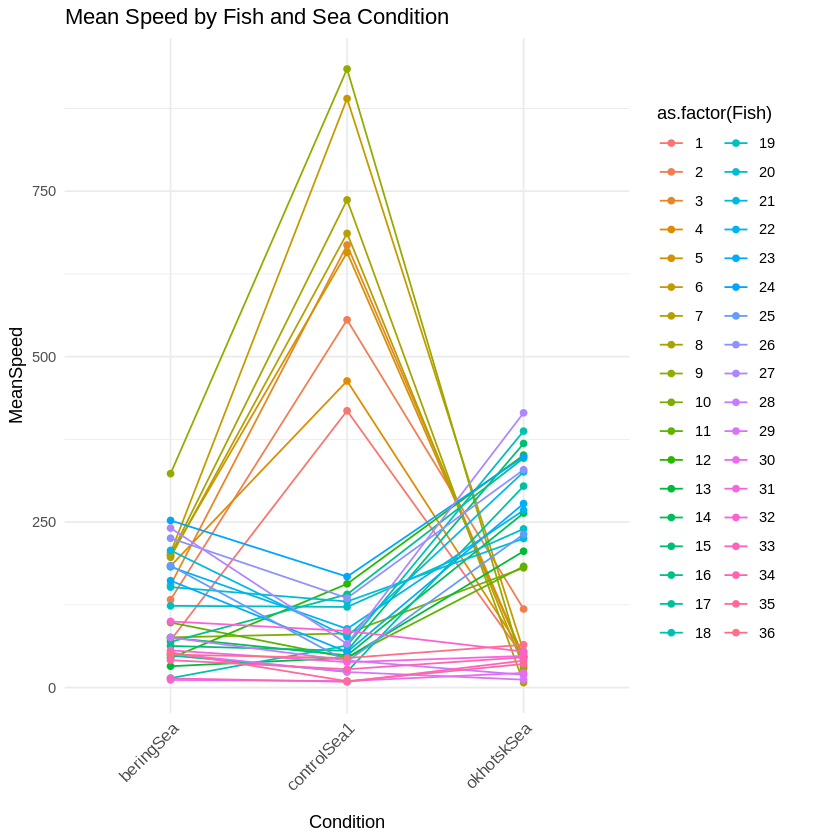

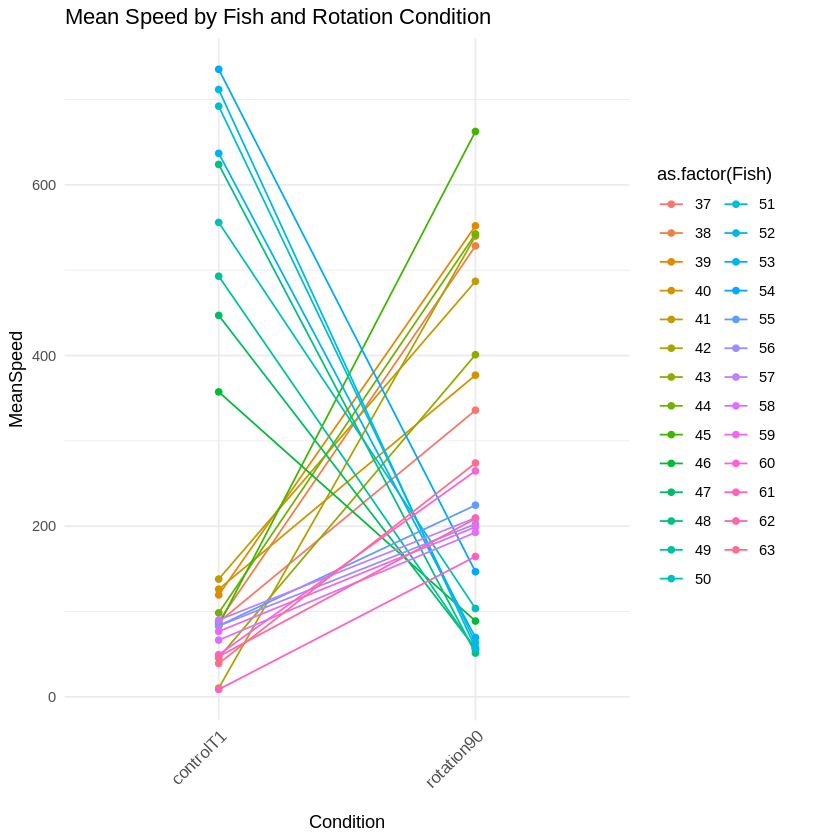

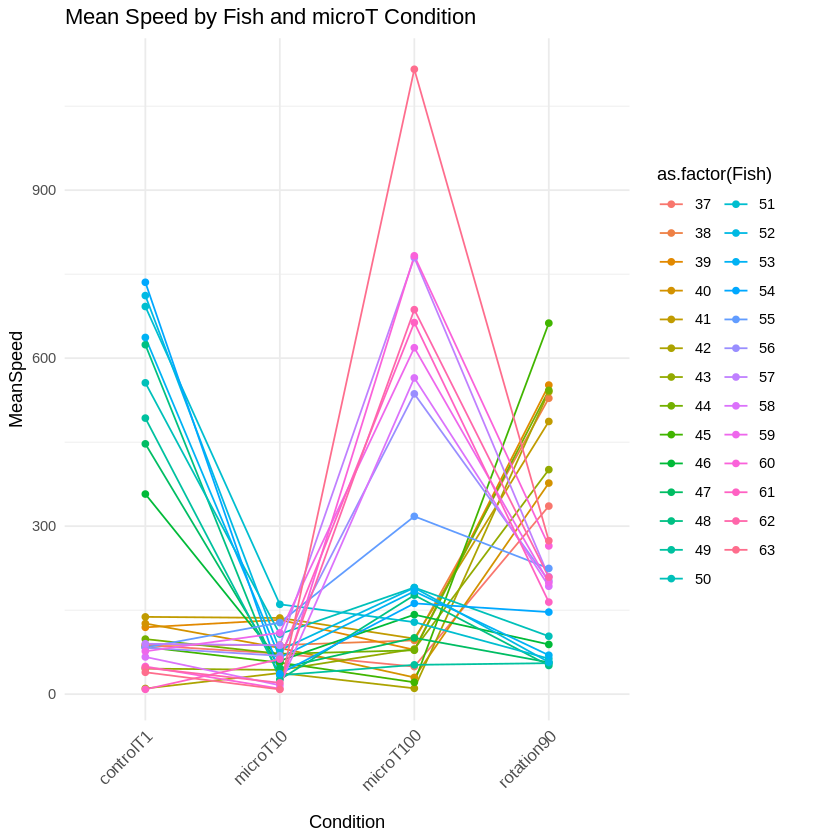

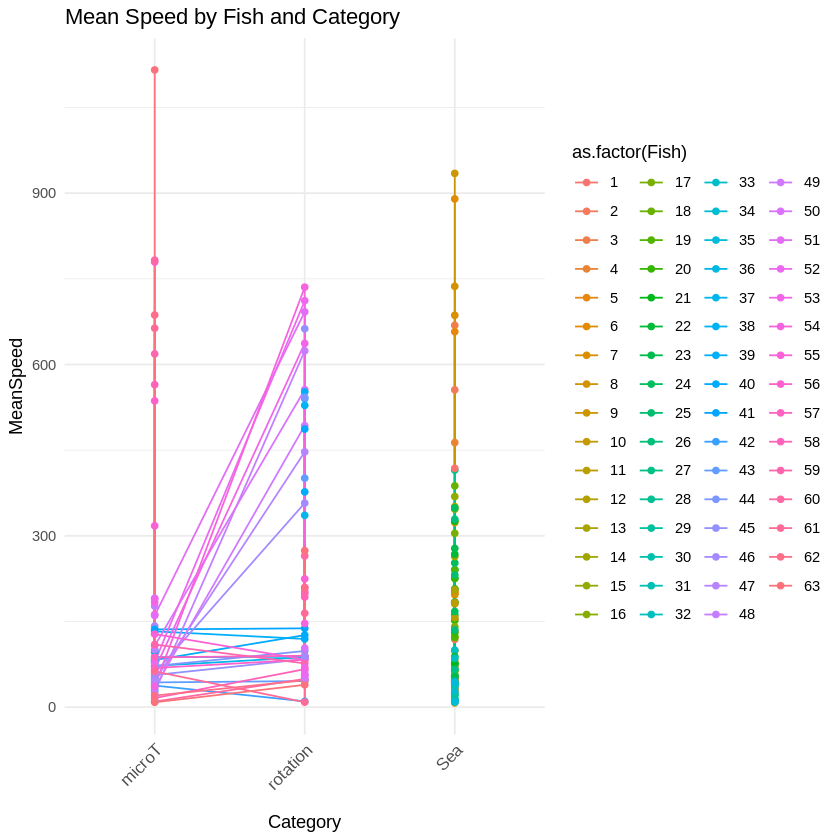

In [ ]:
# 必要なパッケージのインストールとロード
if (!require(circular)) install.packages("circular")
if (!require(multcomp)) install.packages("multcomp")
if (!require(tidyverse)) install.packages("tidyverse")

library(circular)
library(multcomp)
library(tidyverse)

# データの読み込み
#data <- read_csv("data/My Drive/data/speed_heading_data.csv")

# データの前処理
data$Heading <- circular(data$Heading, units="degrees", template="none")

# 定数の定義
fps <- 30
time_limit <- 15 * 60 * fps # 20分をフレーム数に変換
one_minute_frames <- 60 * fps

# 各条件ごとにfish毎の平均値を計算し、20分の時間制限を適用
averaged_data <- data.frame()

conditions <- unique(data$Condition)
fish_ids <- unique(data$Fish)

for (i in 1:length(conditions)) {
  for (j in 1:length(fish_ids)) {
    # 現在の条件と魚のデータをフィルタリング
    condition_fish_data <- data[data$Condition == conditions[i] & data$Fish == fish_ids[j], ]

    # 20分の時間制限を適用
    if (nrow(condition_fish_data) > time_limit) {
      condition_fish_data <- condition_fish_data[(time_limit + 1):nrow(condition_fish_data), ]
    } else {
      next
    }

    # データが存在しない場合は次のループへ
    if (nrow(condition_fish_data) == 0) {
      next
    }

    # 平均値の計算
    mean_speed <- mean(condition_fish_data$Speed, na.rm = TRUE)
    mean_heading <- mean.circular(circular(condition_fish_data$Heading, units = "degrees", template = "geographics"))

    mean_values <- data.frame(
      MeanSpeed = mean_speed,
      MeanHeading = mean_heading,
      Fish = fish_ids[j],
      Condition = conditions[i]
    )

    # 平均値を追加
    averaged_data <- rbind(averaged_data, mean_values)
  }
}

# 条件を海、回転、microTの3つに分類
control_sea <- "controlSea1"
control_rot <- "controlT1"
control_t1 <- "controlT1"

#sea_conditions <- setdiff(conditions[grep("Sea", conditions)], control_sea)
#rot_conditions <- setdiff(conditions[grep("rotation|controlRot2", conditions)], control_rot)
#microt_conditions <- setdiff(conditions[grep("microT|controlT", conditions)], control_t1)

sea_conditions <- conditions[grep("Sea", conditions)]
rot_conditions <- conditions[grep("rotation|controlT", conditions)]
microt_conditions <- conditions[grep("microT|rotation|controlT", conditions)]

# Print the content of sea_conditions
print("Conditions:")
print(sea_conditions)
print(rot_conditions)
print(microt_conditions)

# カテゴリーの追加
averaged_data <- averaged_data %>%
  mutate(Category = case_when(
    Condition %in% sea_conditions ~ "Sea",
   Condition %in% rot_conditions ~ "rotation",
    Condition %in% microt_conditions ~ "microT",
    TRUE ~ "Other"
  ))



# カテゴリー間のANOVAと事後検定
anova_category <- aov(MeanSpeed ~ Category, data = averaged_data)
summary_category <- summary(anova_category)
tukey_category <- TukeyHSD(anova_category)
significant_category <- as.data.frame(tukey_category$Category) %>% filter(`p adj` < 0.05)

# 有意なカテゴリー間ペアを表示
cat("Significant Category Pairs:\n")
print(significant_category)

# ANOVAの詳細結果を表示
cat("\nANOVA Summary for Categories:\n")
print(summary_category)

# 条件ごとのfish毎の平均値のプロット作成
plot_fish_means <- function(data, y, title) {
  ggplot(data, aes(x = Condition, y = get(y), color = as.factor(Fish), group = Fish)) +
    geom_line() +
    geom_point() +
    labs(title = title, y = y) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) # x軸の調整
}

# プロットを表示
plot_speed_sea <- plot_fish_means(averaged_data %>% filter(Condition %in% sea_conditions), "MeanSpeed", "Mean Speed by Fish and Sea Condition")
plot_speed_rot <- plot_fish_means(averaged_data %>% filter(Condition %in% rot_conditions), "MeanSpeed", "Mean Speed by Fish and Rotation Condition")
plot_speed_microt <- plot_fish_means(averaged_data %>% filter(Condition %in% microt_conditions), "MeanSpeed", "Mean Speed by Fish and microT Condition")

print(plot_speed_sea)
print(plot_speed_rot)
print(plot_speed_microt)

# カテゴリーごとの平均値のプロット作成
plot_category_means <- function(data, y, title) {
  ggplot(data, aes(x = Category, y = get(y), color = as.factor(Fish), group = Fish)) +
    geom_line() +
    geom_point() +
    labs(title = title, y = y) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) # x軸の調整
}

# プロットを表示
plot_speed_category <- plot_category_means(averaged_data, "MeanSpeed", "Mean Speed by Fish and Category")

print(plot_speed_category)
